# Activity 1.4 - COVID-19 open data, Mexico 2020

**Seminario de Ciencia de Datos - Eliezer Lagunes Portela**

Source: Direccion General de Epidemiologia, Secretaria de Salud, Mexico.
Portal indicated in the activity: <https://www.gob.mx/salud/documentos/datos-abiertos-152127>

The file used is the historical closing of the year 2020, cut of 31 December 2020:

`https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/historicos/12/datos_abiertos_covid19_31.12.2020.zip`

It contains `201231COVID19MEXICO.csv`, 3,628,951 records and 40 variables.
The codes of the categorical variables come from the official data dictionary
that accompanies the download.

Tools used: KDE and bar plots.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import urllib.request
import zipfile

URL = "https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/historicos/12/datos_abiertos_covid19_31.12.2020.zip"
ZIP = "datos_abiertos_covid19_31.12.2020.zip"
CSV = "201231COVID19MEXICO.csv"

#Download and unzip only if the csv is not already in the folder
if not os.path.exists(CSV):
    if not os.path.exists(ZIP):
        print("Downloading the database, about 74 MB")
        urllib.request.urlretrieve(URL, ZIP)
    print("Unzipping")
    with zipfile.ZipFile(ZIP) as z:
        z.extractall(".")

#The size is printed in bytes and in both conventions, so that the cut used can be identified
#without ambiguity. Excel cannot open this file, it has more rows than the 1,048,576 that Excel allows
bytes_csv = os.path.getsize(CSV)
print("File ready", CSV)
print("Size in bytes", bytes_csv)
print("Size in MB (base 10)", round(bytes_csv / 1000**2, 1))
print("Size in MiB (what Windows shows as MB)", round(bytes_csv / 1024**2, 1))

File ready 201231COVID19MEXICO.csv
Size in bytes 588383684
Size in MB (base 10) 588.4
Size in MiB (what Windows shows as MB) 561.1


In [2]:
#The file is encoded in latin-1, not utf-8. Only the columns of interest are read
columnas = ["SEXO", "ENTIDAD_RES", "TIPO_PACIENTE", "FECHA_INGRESO", "FECHA_SINTOMAS",
            "FECHA_DEF", "INTUBADO", "NEUMONIA", "EDAD", "DIABETES", "HIPERTENSION",
            "OBESIDAD", "TABAQUISMO", "CLASIFICACION_FINAL", "UCI"]

datos = pd.read_csv(CSV, usecols=columnas, encoding="latin-1", low_memory=False)
print("Records", datos.shape[0], "Variables read", datos.shape[1])
datos.head()

Records 3628951 Variables read 15


,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,DIABETES,HIPERTENSION,OBESIDAD,TABAQUISMO,CLASIFICACION_FINAL,UCI
0,2,23,1,2020-03-30,2020-03-20,9999-99-99,97,2,37,2,2,2,2,3,97
1,1,5,1,2020-04-03,2020-03-30,9999-99-99,97,2,64,2,2,2,2,3,97
2,2,3,1,2020-04-07,2020-03-30,9999-99-99,97,2,33,2,2,2,2,3,97
3,2,12,2,2020-03-31,2020-03-24,2020-04-04,1,1,28,2,2,2,2,3,1
4,2,9,2,2020-04-01,2020-03-26,9999-99-99,2,2,46,2,2,2,2,3,2


In [3]:
#CLASIFICACION_FINAL: 1, 2 and 3 are confirmed cases, 4 invalid, 5 not carried out,
#6 suspicious and 7 negative. Only the confirmed cases are analysed
print("Distribution of CLASIFICACION_FINAL")
print(datos["CLASIFICACION_FINAL"].value_counts().sort_index())

casos = datos[datos["CLASIFICACION_FINAL"].isin([1, 2, 3])].copy()
print("Confirmed cases in 2020", len(casos))

Distribution of CLASIFICACION_FINAL
CLASIFICACION_FINAL
1      54533
2       2193
3    1369368
4       9795
5      54698
6     343416
7    1794948
Name: count, dtype: int64


Confirmed cases in 2020 1426094


In [4]:
#Derived variables. FECHA_DEF equal to 9999-99-99 means that the patient did not die
casos["FECHA_SINTOMAS"] = pd.to_datetime(casos["FECHA_SINTOMAS"], errors="coerce")
casos["FECHA_INGRESO"] = pd.to_datetime(casos["FECHA_INGRESO"], errors="coerce")
casos["DEFUNCION"] = casos["FECHA_DEF"] != "9999-99-99"
casos["RETRASO"] = (casos["FECHA_INGRESO"] - casos["FECHA_SINTOMAS"]).dt.days

print("Case fatality rate in percent", round(100 * casos["DEFUNCION"].mean(), 2))
casos[["EDAD", "RETRASO"]].describe().round(2)

Case fatality rate in percent 8.82


,EDAD,RETRASO
count,1426094.00,1426094.00
mean,43.84,4.15
std,16.85,3.30
min,0.00,0.00
25%,31.00,2.00
50%,43.00,4.00
75%,55.00,6.00
max,120.00,80.00


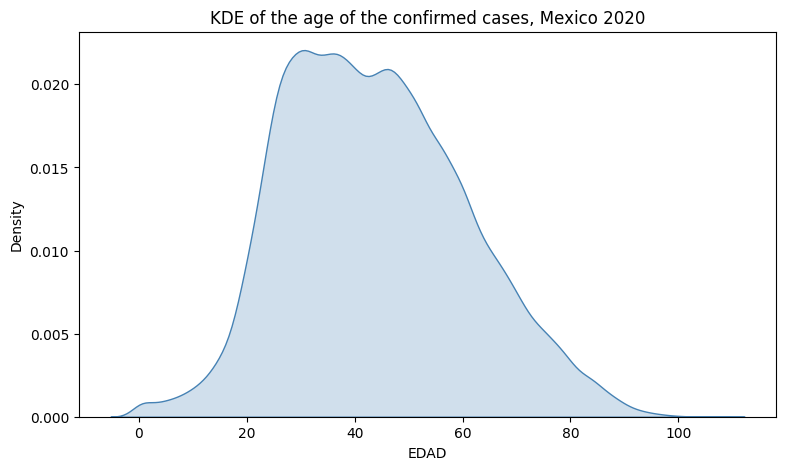

Mode of the KDE 30.6
Mean 43.8  Median 43.0


In [5]:
#KDE of the age of the confirmed cases
muestra = casos.sample(80000, random_state=1) #A sample is used, the KDE on 1.4 million rows is very slow

plt.figure(figsize=(9, 5))
sns.kdeplot(data=muestra, x="EDAD", fill=True, color="steelblue")
plt.title("KDE of the age of the confirmed cases, Mexico 2020")
plt.show()

from scipy.stats import gaussian_kde
edad = casos["EDAD"]
kde = gaussian_kde(muestra["EDAD"])
malla = np.linspace(0, 110, 1000)
print("Mode of the KDE", round(malla[np.argmax(kde(malla))], 1))
print("Mean", round(edad.mean(), 1), " Median", edad.median())

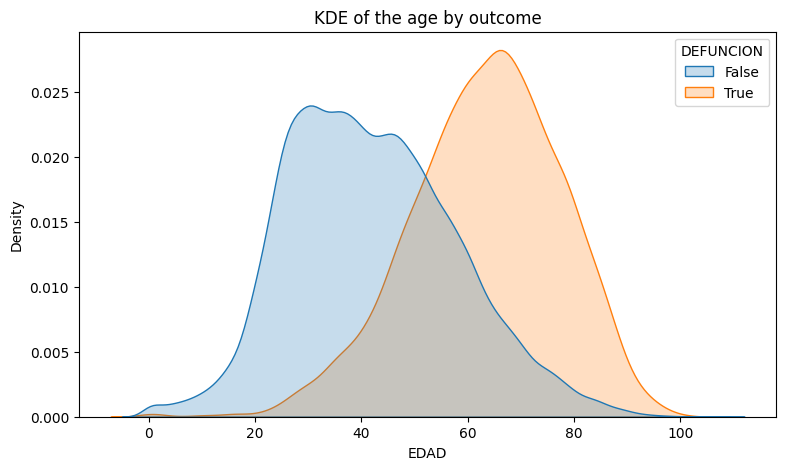

survivors  mode 29.9  mean 42.0  median 41.0


deaths  mode 65.0  mean 63.0  median 64.0


In [6]:
#KDE of the age separating survivors from deaths. This is where the KDE is most useful
plt.figure(figsize=(9, 5))
sns.kdeplot(data=muestra, x="EDAD", hue="DEFUNCION", fill=True, common_norm=False)
plt.title("KDE of the age by outcome")
plt.show()

for etiqueta, sub in [("survivors", casos[~casos["DEFUNCION"]]), ("deaths", casos[casos["DEFUNCION"]])]:
    k = gaussian_kde(sub["EDAD"].sample(min(40000, len(sub)), random_state=1))
    print(etiqueta, " mode", round(malla[np.argmax(k(malla))], 1),
          " mean", round(sub["EDAD"].mean(), 1),
          " median", sub["EDAD"].median())

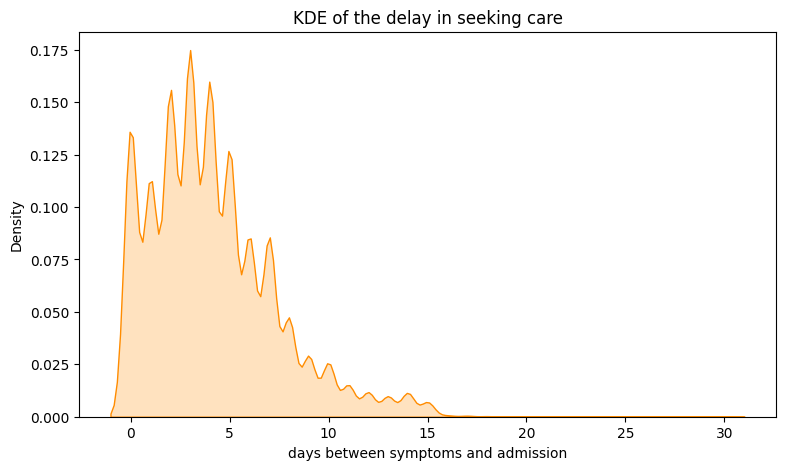

Mode of the KDE 3.01
Median 4.0  Percentile 90 8.0


In [7]:
#KDE of the delay in days between the onset of symptoms and the admission
retraso = casos["RETRASO"]
retraso = retraso[(retraso >= 0) & (retraso <= 30)]

plt.figure(figsize=(9, 5))
sns.kdeplot(x=retraso.sample(80000, random_state=1), fill=True, color="darkorange")
plt.xlabel("days between symptoms and admission")
plt.title("KDE of the delay in seeking care")
plt.show()

k = gaussian_kde(retraso.sample(80000, random_state=1))
malla2 = np.linspace(0, 30, 600)
print("Mode of the KDE", round(malla2[np.argmax(k(malla2))], 2))
print("Median", retraso.median(), " Percentile 90", np.percentile(retraso, 90))

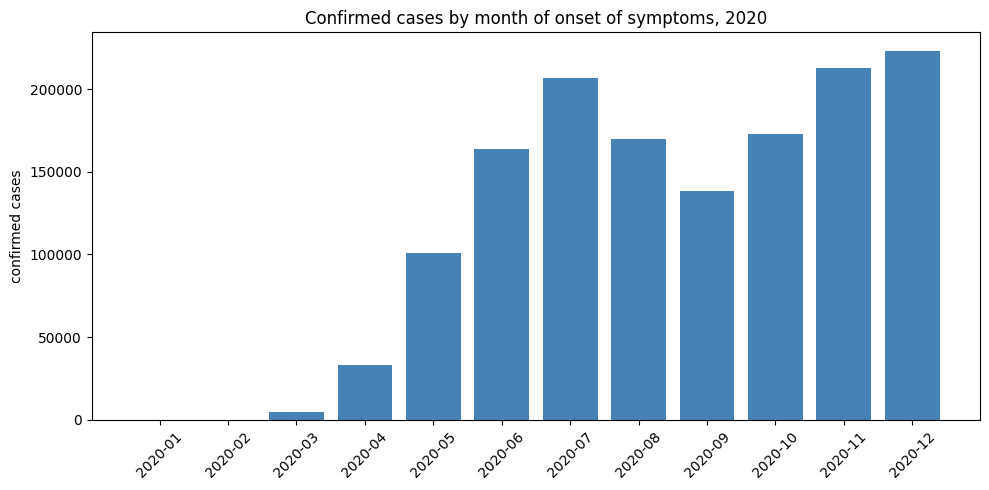

FECHA_SINTOMAS
2020-01         3
2020-02        19
2020-03      4370
2020-04     33180
2020-05    100606
2020-06    163910
2020-07    206717
2020-08    169849
2020-09    138229
2020-10    172850
2020-11    213031
2020-12    223330
Freq: M, Name: count, dtype: int64


In [8]:
#Bar plot of the confirmed cases by month of onset of symptoms
por_mes = casos["FECHA_SINTOMAS"].dt.to_period("M").value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(por_mes.index.astype(str), por_mes.values, color="steelblue")
plt.xticks(rotation=45)
plt.ylabel("confirmed cases")
plt.title("Confirmed cases by month of onset of symptoms, 2020")
plt.tight_layout()
plt.show()

print(por_mes)

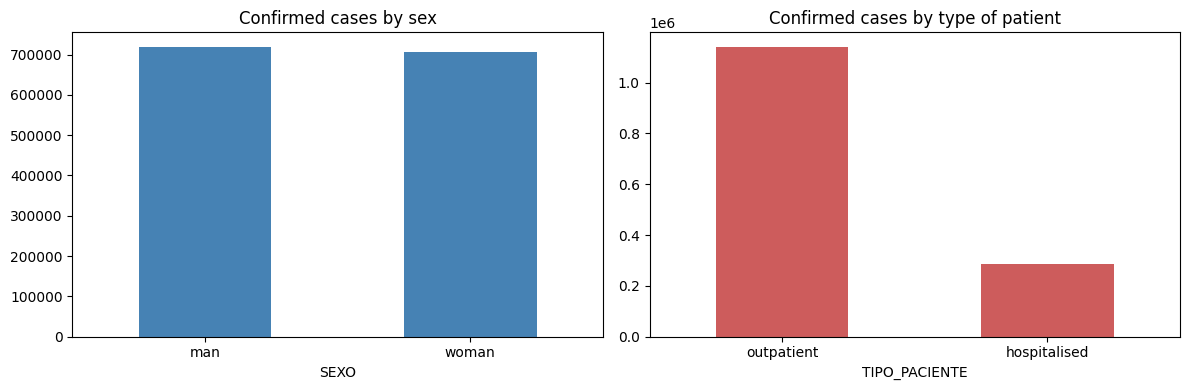

Case fatality rate by sex in percent
SEXO
man      11.10
woman     6.51
Name: DEFUNCION, dtype: float64
Case fatality rate by type of patient in percent
TIPO_PACIENTE
hospitalised    39.52
outpatient       1.14
Name: DEFUNCION, dtype: float64


In [9]:
#Bar plots of sex and type of patient. SEXO: 1 woman, 2 man. TIPO_PACIENTE: 1 outpatient, 2 hospitalised
sexo = casos["SEXO"].map({1: "woman", 2: "man"})
tipo = casos["TIPO_PACIENTE"].map({1: "outpatient", 2: "hospitalised"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sexo.value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Confirmed cases by sex")
tipo.value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Confirmed cases by type of patient")
for a in axes:
    a.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Case fatality rate by sex in percent")
print((100 * casos.groupby(sexo)["DEFUNCION"].mean()).round(2))
print("Case fatality rate by type of patient in percent")
print((100 * casos.groupby(tipo)["DEFUNCION"].mean()).round(2))

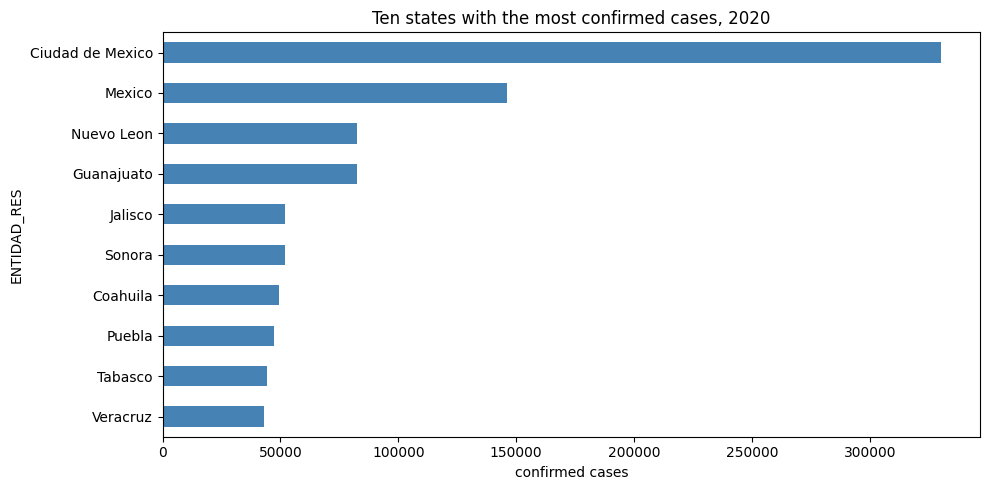

ENTIDAD_RES
Ciudad de Mexico    330273
Mexico              146199
Nuevo Leon           82595
Guanajuato           82517
Jalisco              51994
Sonora               51708
Coahuila             49427
Puebla               47283
Tabasco              44248
Veracruz             43128
Name: count, dtype: int64


In [10]:
#Bar plot of the ten states of residence with the most confirmed cases
estados = {1:"Aguascalientes",2:"Baja California",3:"Baja California Sur",4:"Campeche",5:"Coahuila",
           6:"Colima",7:"Chiapas",8:"Chihuahua",9:"Ciudad de Mexico",10:"Durango",11:"Guanajuato",
           12:"Guerrero",13:"Hidalgo",14:"Jalisco",15:"Mexico",16:"Michoacan",17:"Morelos",
           18:"Nayarit",19:"Nuevo Leon",20:"Oaxaca",21:"Puebla",22:"Queretaro",23:"Quintana Roo",
           24:"San Luis Potosi",25:"Sinaloa",26:"Sonora",27:"Tabasco",28:"Tamaulipas",29:"Tlaxcala",
           30:"Veracruz",31:"Yucatan",32:"Zacatecas"}

top = casos["ENTIDAD_RES"].map(estados).value_counts().head(10)

plt.figure(figsize=(10, 5))
top.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("confirmed cases")
plt.title("Ten states with the most confirmed cases, 2020")
plt.tight_layout()
plt.show()

print(top)

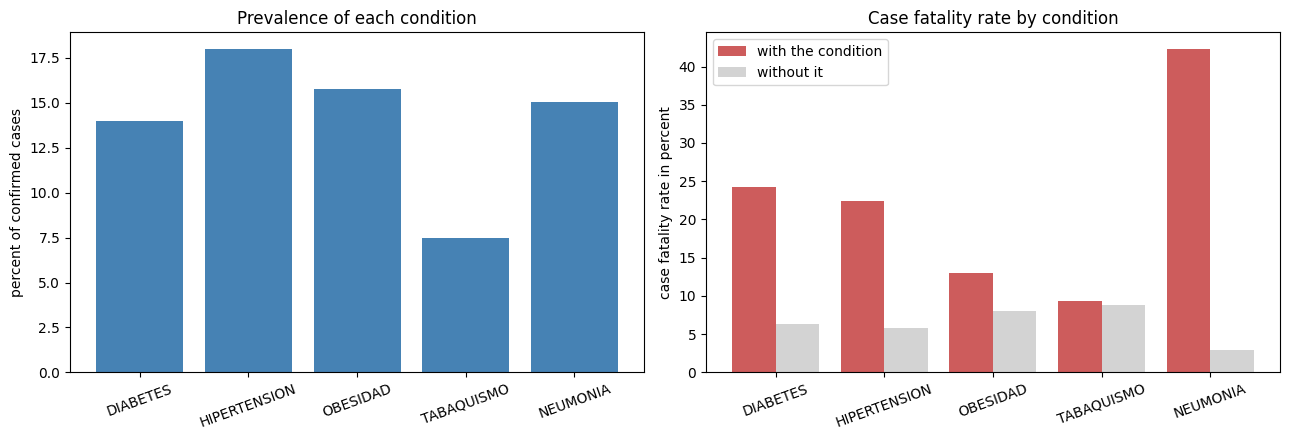

,prevalence,fatality_with,fatality_without
DIABETES,13.99,24.28,6.27
HIPERTENSION,18.02,22.43,5.79
OBESIDAD,15.79,13.02,8.00
TABAQUISMO,7.50,9.38,8.75
NEUMONIA,15.06,42.36,2.88


In [11]:
#Bar plots of the comorbidities. Code 1 is yes, 2 is no, 97, 98 and 99 are not applicable or unknown
comorbilidades = ["DIABETES", "HIPERTENSION", "OBESIDAD", "TABAQUISMO", "NEUMONIA"]

prevalencia = {}
letalidad_si = {}
letalidad_no = {}
for v in comorbilidades:
    prevalencia[v] = 100 * (casos[v] == 1).mean()
    letalidad_si[v] = 100 * casos.loc[casos[v] == 1, "DEFUNCION"].mean()
    letalidad_no[v] = 100 * casos.loc[casos[v] == 2, "DEFUNCION"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(list(prevalencia.keys()), list(prevalencia.values()), color="steelblue")
axes[0].set_ylabel("percent of confirmed cases")
axes[0].set_title("Prevalence of each condition")

x = np.arange(len(comorbilidades))
axes[1].bar(x - 0.2, list(letalidad_si.values()), width=0.4, color="indianred", label="with the condition")
axes[1].bar(x + 0.2, list(letalidad_no.values()), width=0.4, color="lightgray", label="without it")
axes[1].set_xticks(x)
axes[1].set_xticklabels(comorbilidades)
axes[1].set_ylabel("case fatality rate in percent")
axes[1].set_title("Case fatality rate by condition")
axes[1].legend()
for a in axes:
    a.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

resumen = pd.DataFrame({"prevalence": prevalencia, "fatality_with": letalidad_si, "fatality_without": letalidad_no})
resumen.round(2)

## Findings

**1. Most of the file is not confirmed cases.** The 2020 closing has 3,628,951 records but only
1,426,094 of them (39.3 %) are confirmed cases. 1,794,948 came out negative, 343,416 stayed as
suspicious and 54,698 never got a test. If you use the whole file without filtering
`CLASIFICACION_FINAL` you are describing how much testing was done, not the epidemic.

**2. The KDE of age hides two populations until you split it.** Over all the confirmed cases the
density leans to the right, with the mode at 30.6 years, a mean of 43.8 and a median of 43 (the mode
comes from the sample of 80,000 records used for the KDE). Split by outcome, the two curves almost
do not overlap. Survivors keep the mode at 29.9 years and a mean of 42.0. Deaths move the mode to
65.0 and the mean to 63.0, about 22 years higher. Survivors are 91 % of the cases, so they pull the
whole density towards them and the risk group only shows up after conditioning on the outcome.

**3. People went to the hospital fast.** The KDE of the days between symptoms and admission has the
mode at 3 days, a median of 4 and a percentile 90 of 8 days. It is very skewed to the right. Almost
everybody went within the first week, but the tail goes up to 80 days.

**4. The bar plot by month shows the two waves of 2020.** Cases start growing in March, peak in
July with 206,717, drop in September to 138,229 and grow again until December, which ends as the
worst month of the year with 223,330.

**5. Being hospitalised is the strongest risk marker.** There were 1,140,595 outpatients and
285,499 hospitalised, but the fatality rate goes from 1.14 % to 39.52 %. Sex also matters. The cases
are almost even, 707,040 women and 719,054 men, but the fatality rate is 6.51 % for women and
11.10 % for men.

**6. Pneumonia matters more than the chronic conditions.** It appears in 15.1 % of the confirmed
cases and moves the fatality rate from 2.9 % to 42.4 %. Diabetes (14.0 % of the cases) moves it from
6.3 % to 24.3 % and hypertension (18.0 %) from 5.8 % to 22.4 %. Smoking is in 7.5 % of the cases and
almost does not change it, 9.4 % against 8.7 %. So not every condition in the file says something
about the outcome.

**7. The cases are concentrated in a few states.** Mexico City alone has 330,273 confirmed cases,
23.2 % of the country, and together with the State of Mexico (146,199) they hold more than a third
of the year. Part of this is probably more testing in the centre of the country, not only more
cases.